Visualization the overall_matrix: dataset\out_R\R_overall_matrix.csv

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  
from pathlib import Path

region_names = ["California", "Texas", "Germany", "Turkey", "Egypt", "Vietnam", "Nigeria", "India", "Saudi"]

In [9]:
output_path = "dataset\\AA1_first_batch\\analysis_pp_output\\img"
path = r"dataset\AA1_first_batch\analysis_pp_output\pp_average_diff_rate.csv" # 
# path = r"dataset\AA1_first_batch\AA2_second_100_batch\analysis_pp_output\TP_region_pair_matrix.csv"


overall_matrix = pd.read_csv(path, index_col=0)

# Method 1: Drop and reassign directly (recommended; follows Pandas best practices more closely)
overall_matrix = overall_matrix.drop(columns=['Bangladesh', 'Pakistan'])

sorted_df = overall_matrix.reindex(index=region_names, columns=region_names)

sorted_df.head()

,California,Texas,Germany,Turkey,Egypt,Vietnam,Nigeria,India,Saudi
California,0.000000,0.000000,0.018301,0.036601,0.024837,0.014379,0.028758,0.018301,0.026144
Texas,0.000000,0.000000,0.018301,0.036601,0.024837,0.014379,0.028758,0.018301,0.026144
Germany,0.018301,0.018301,0.000000,0.039216,0.016993,0.006536,0.013072,0.010458,0.015686
Turkey,0.036601,0.036601,0.039216,0.000000,0.053595,0.037908,0.039216,0.031373,0.054902
Egypt,0.024837,0.024837,0.016993,0.053595,0.000000,0.020915,0.014379,0.024837,0.001307


In [5]:
def plot_overall_diff_matrix(
    sorted_df,
    # title="Pairwise Regional Regulation Difference",
    figsize=(10, 8),
    cmap="YlOrRd",
    annot=True,
    annot_fontsize=10,
    annot_color="black",
    tick_fontsize=11,
    title_fontsize=15,
    label_fontsize=12,
    colorbar_fontsize=11,
    rotation_x=45,
    rotation_y=0,
    vmin=None,
    vmax=None,
    save_path=None,
    dpi=300
):
    """
    Visualize sorted_df as a confusion-matrix-like heatmap.

    Parameters
    ----------
    sorted_df : pd.DataFrame
        Square matrix. Rows and columns are region names.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    cmap : str
        Matplotlib colormap, e.g., "YlOrRd", "Reds", "Blues", "viridis".
    annot : bool
        Whether to show numbers in cells.
    annot_fontsize : int
        Font size of cell numbers.
    annot_color : str
        Color of cell numbers.
    tick_fontsize : int
        Font size of region labels.
    title_fontsize : int
        Font size of title.
    label_fontsize : int
        Font size of x/y labels.
    colorbar_fontsize : int
        Font size of colorbar labels.
    rotation_x : int
        Rotation angle of x-axis labels.
    rotation_y : int
        Rotation angle of y-axis labels.
    vmin, vmax : int or float
        Color scale range. If None, use matrix min/max.
    save_path : str or None
        If provided, save figure to this path.
    dpi : int
        Resolution for saved figure.
    """

    regions = sorted_df.index.tolist()
    data = sorted_df.values

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # Axis ticks
    ax.set_xticks(np.arange(len(regions)))
    ax.set_yticks(np.arange(len(regions)))

    ax.set_xticklabels(
        regions,
        fontsize=tick_fontsize,
        rotation=rotation_x,
        ha="right"
    )
    ax.set_yticklabels(
        regions,
        fontsize=tick_fontsize,
        rotation=rotation_y
    )

    # Axis labels and title
    # ax.set_xlabel("Region", fontsize=label_fontsize)
    # ax.set_ylabel("Region", fontsize=label_fontsize)
    # ax.set_title(title, fontsize=title_fontsize, pad=15)

    # Add numbers inside cells
    if annot:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                if data[i, j] != 0:
                    # First format to two decimal places (e.g., "0.08" or "1.25")
                    val_str = f"{data[i, j]:.4f}"
                    
                    # If it starts with "0.", remove the leading "0" to get ".08"
                    if val_str.startswith("0."):
                        val_str = val_str[1:]
                    # If it starts with "-0.", change it to "-.08"
                    elif val_str.startswith("-0."):
                        val_str = "-" + val_str[2:]
                        
                    ax.text(
                        j,
                        i,
                        val_str,
                        ha="center",
                        va="center",
                        fontsize=annot_fontsize,
                        color=annot_color
                    )

    # Grid lines, similar to confusion matrix
    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Difference Count", fontsize=colorbar_fontsize)
    cbar.ax.tick_params(labelsize=colorbar_fontsize)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

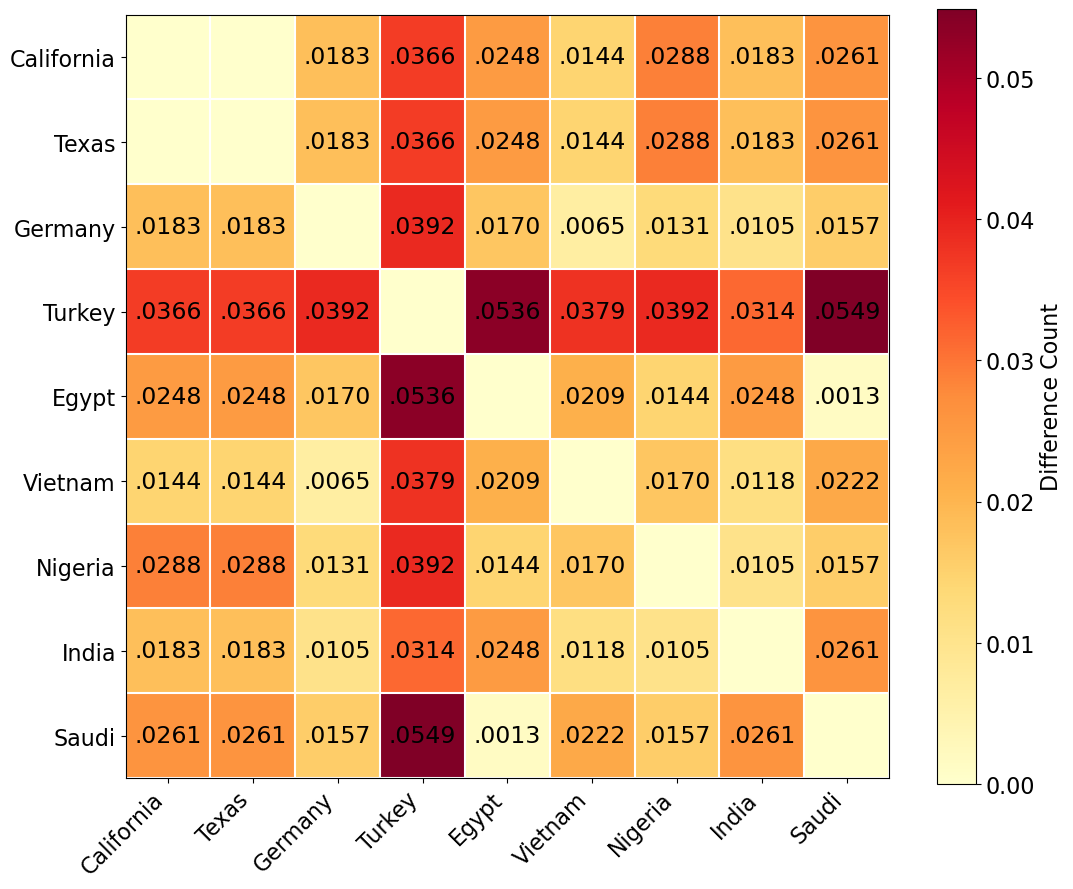

In [10]:
overall_matrix_save_path = output_path + "\\PP_overall_matrix.pdf" 
# overall_matrix_save_path = output_path + "\\PP_TP_region_pair_matrix.pdf" #
overall_matrix_save_path = Path(overall_matrix_save_path)
overall_matrix_save_path.parent.mkdir(parents=True, exist_ok=True)

plot_overall_diff_matrix(
    sorted_df,
    # title="Overall Pairwise Regulation Difference",
    figsize=(11, 9),
    cmap= "YlOrRd", #"viridis", #"YlOrRd",
    annot=True,
    annot_fontsize=17,
    annot_color="black",
    tick_fontsize=16,
    title_fontsize=16,
    label_fontsize=16,
    colorbar_fontsize=16,
    rotation_x=45,
    save_path=overall_matrix_save_path
)

In [28]:
output_path_matched = "dataset\\AA1_first_batch\\AA2_second_100_batch\\analysis_pp_output\\img"

path_matched = "dataset\\AA1_first_batch\\AA2_second_100_batch\\analysis_pp_output\\PP_matched_R_overall_matrix.csv"

overall_matrix = pd.read_csv(path_matched, index_col=0)
sorted_df = overall_matrix.reindex(index=region_names, columns=region_names)

sorted_df.head()

,California,Texas,Germany,Turkey,Egypt,Vietnam,Nigeria,India,Saudi,Bangladesh,Pakistan
California,0.000000,0.000000,0.022222,0.083333,0.071429,0.000000,0.017857,0.078431,0.116667,0.022222,0.022222
Texas,0.000000,0.000000,0.083333,0.066667,0.035714,0.000000,0.000000,0.058824,0.066667,0.000000,0.000000
Germany,0.022222,0.083333,0.000000,0.245098,0.066667,0.022222,0.000000,0.093750,0.088889,0.000000,0.062500
Turkey,0.083333,0.066667,0.245098,0.000000,0.133333,0.145833,0.031250,0.066667,0.142157,0.066667,0.066667
Egypt,0.071429,0.035714,0.066667,0.133333,0.000000,0.000000,0.033333,0.035714,0.000000,0.000000,0.000000


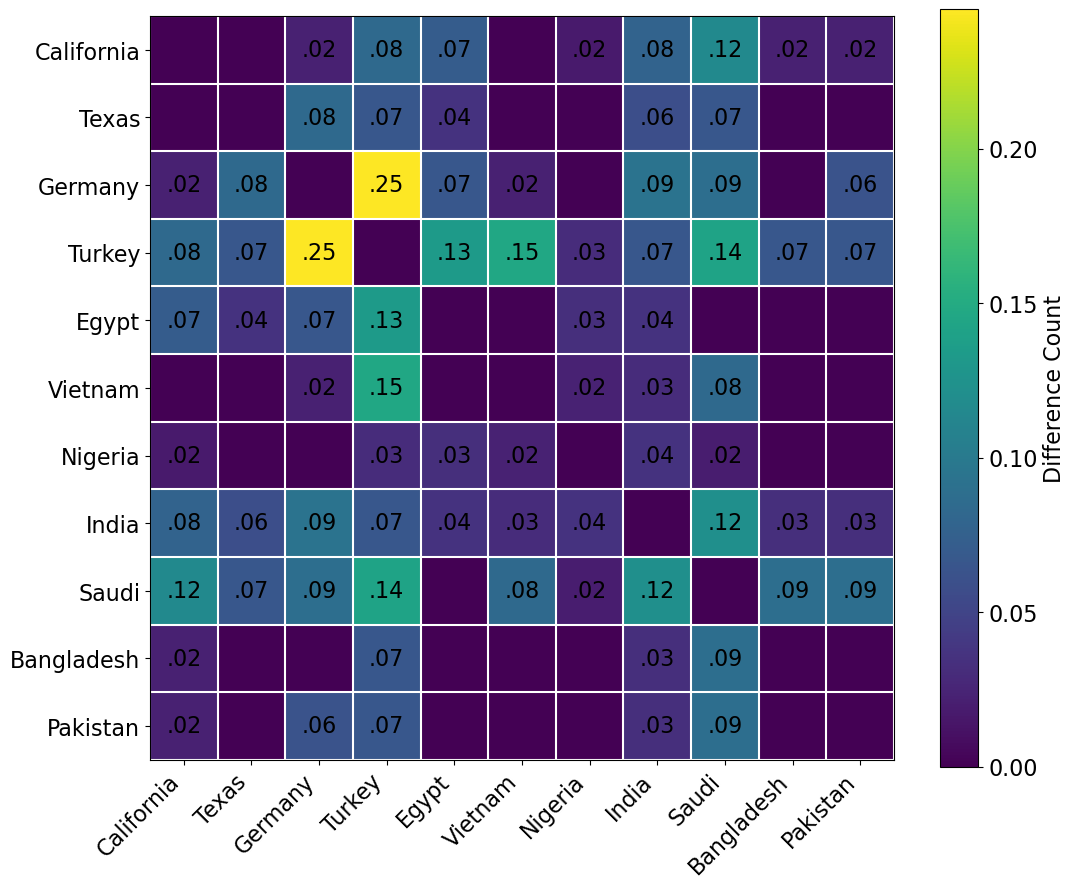

In [29]:
overall_matrix_save_path = output_path_matched + "\\pp_matched_R_overall_matrix.pdf" 

plot_overall_diff_matrix(
    sorted_df,
    # title="Overall Pairwise Regulation Difference",
    figsize=(11, 9),
    cmap= "viridis", #"viridis", #"YlOrRd",
    annot=True,
    annot_fontsize=16,
    annot_color="black",
    tick_fontsize=16,
    title_fontsize=16,
    label_fontsize=16,
    colorbar_fontsize=16,
    rotation_x=45,
    save_path=overall_matrix_save_path
)

## For numeric values

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  

region_names = ["California", "Texas", "Germany", "Turkey", "Egypt", "Vietnam", "Nigeria", "India", "Saudi"]

In [15]:
output_path = "dataset\\AA1_first_batch\\analysis_pp_output\\img"
path = r"dataset\AA1_first_batch\analysis_pp_output\PP_TP_by_region_pair.csv"


overall_matrix = pd.read_csv(path, index_col=0)
# Method 1: Drop and reassign directly (recommended; follows Pandas best practices more closely)
# overall_matrix = overall_matrix.drop(columns=['Bangladesh', 'Pakistan'])

sorted_df = overall_matrix.reindex(index=region_names, columns=region_names)

sorted_df.head()

,California,Texas,Germany,Turkey,Egypt,Vietnam,Nigeria,India,Saudi
California,0,0,2,15,3,2,5,4,8
Texas,0,0,2,6,2,1,4,1,6
Germany,2,2,0,11,1,0,2,3,7
Turkey,15,6,11,0,7,8,6,4,10
Egypt,3,2,1,7,0,1,3,1,0


In [16]:
def plot_overall_diff_matrix(
    sorted_df,
    # title="Pairwise Regional Regulation Difference",
    figsize=(10, 8),
    cmap="YlOrRd",
    annot=True,
    annot_fontsize=10,
    annot_color="black",
    tick_fontsize=11,
    title_fontsize=15,
    label_fontsize=12,
    colorbar_fontsize=11,
    rotation_x=45,
    rotation_y=0,
    vmin=None,
    vmax=None,
    save_path=None,
    dpi=300
):
    """
    Visualize sorted_df as a confusion-matrix-like heatmap.

    Parameters
    ----------
    sorted_df : pd.DataFrame
        Square matrix. Rows and columns are region names.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    cmap : str
        Matplotlib colormap, e.g., "YlOrRd", "Reds", "Blues", "viridis".
    annot : bool
        Whether to show numbers in cells.
    annot_fontsize : int
        Font size of cell numbers.
    annot_color : str
        Color of cell numbers.
    tick_fontsize : int
        Font size of region labels.
    title_fontsize : int
        Font size of title.
    label_fontsize : int
        Font size of x/y labels.
    colorbar_fontsize : int
        Font size of colorbar labels.
    rotation_x : int
        Rotation angle of x-axis labels.
    rotation_y : int
        Rotation angle of y-axis labels.
    vmin, vmax : int or float
        Color scale range. If None, use matrix min/max.
    save_path : str or None
        If provided, save figure to this path.
    dpi : int
        Resolution for saved figure.
    """

    regions = sorted_df.index.tolist()
    data = sorted_df.values

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # Axis ticks
    ax.set_xticks(np.arange(len(regions)))
    ax.set_yticks(np.arange(len(regions)))

    ax.set_xticklabels(
        regions,
        fontsize=tick_fontsize,
        rotation=rotation_x,
        ha="right"
    )
    ax.set_yticklabels(
        regions,
        fontsize=tick_fontsize,
        rotation=rotation_y
    )

    # Axis labels and title
    # ax.set_xlabel("Region", fontsize=label_fontsize)
    # ax.set_ylabel("Region", fontsize=label_fontsize)
    # ax.set_title(title, fontsize=title_fontsize, pad=15)

    # Add numbers inside cells
    if annot:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                if data[i, j] != 0:
                    # # First format to two decimal places (e.g., "0.08" or "1.25")
                    # val_str = f"{data[i, j]:.4f}"
                    
                    # # If it starts with "0.", remove the leading "0" to get ".08"
                    # if val_str.startswith("0."):
                    #     val_str = val_str[1:]
                    # # If it starts with "-0.", change it to "-.08"
                    # elif val_str.startswith("-0."):
                    #     val_str = "-" + val_str[2:]
                        
                    ax.text(
                        j,
                        i,
                        data[i, j],
                        ha="center",
                        va="center",
                        fontsize=annot_fontsize,
                        color=annot_color
                    )

    # Grid lines, similar to confusion matrix
    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Difference Count", fontsize=colorbar_fontsize)
    cbar.ax.tick_params(labelsize=colorbar_fontsize)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

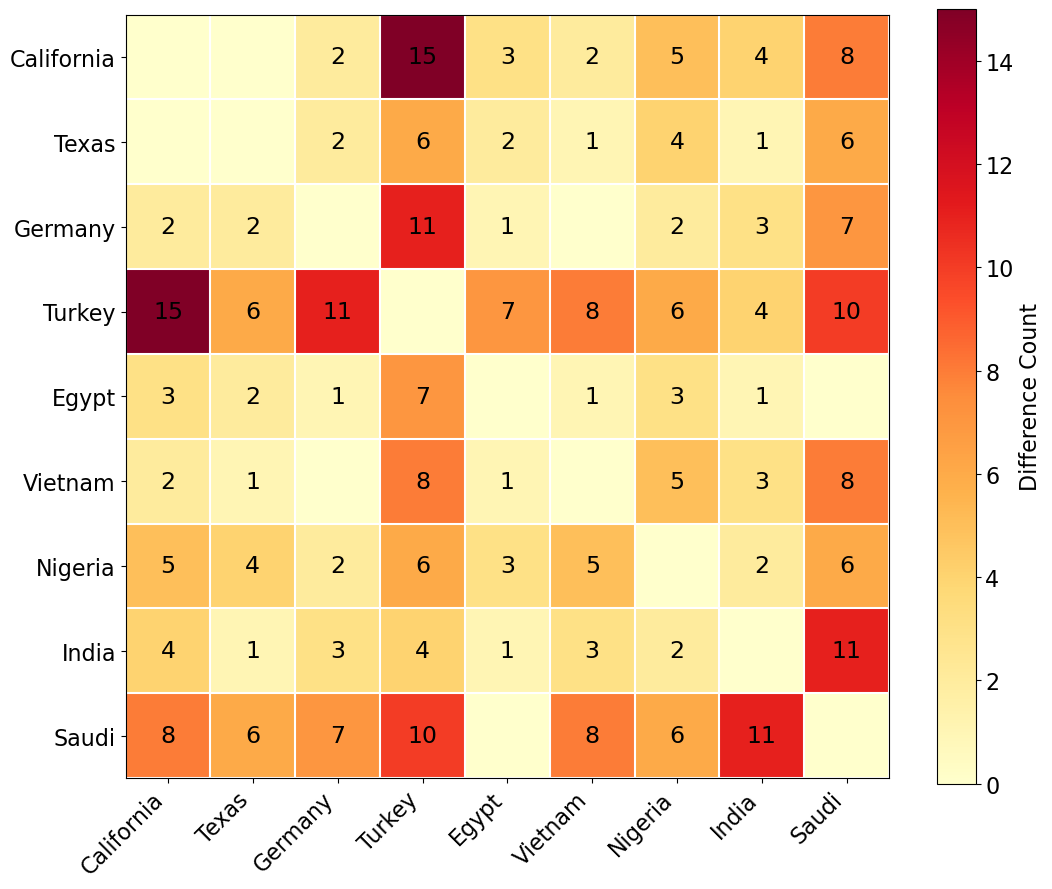

In [17]:
overall_matrix_save_path = output_path + "\\PP_TP_region_pair_matrix.pdf" #

plot_overall_diff_matrix(
    sorted_df,
    # title="Overall Pairwise Regulation Difference",
    figsize=(11, 9),
    cmap= "YlOrRd", #"viridis", #"YlOrRd",
    annot=True,
    annot_fontsize=17,
    annot_color="black",
    tick_fontsize=16,
    title_fontsize=16,
    label_fontsize=16,
    colorbar_fontsize=16,
    rotation_x=45,
    save_path=overall_matrix_save_path
)